In [3]:
import torch
from torch.nn.functional import softmax
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import nltk
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt
import pandas as pd
import re

#load pretrained model
model_name = "bhadresh-savani/bert-base-go-emotion"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

#full GoEmotions label list~
labels = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring", "confusion", "curiosity",
    "desire", "disappointment", "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral"
]

def analyze_emotions_explicit(filepath):
    # Load text
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()
    # use re to clean the text
    text = re.sub(r'\s+', ' ', text)  # Normalize spaces
    sentences = re.findall(r'.+?[.!?](?=\s|$)', text)  # Keep punctuation
    sentences = [s.strip() for s in sentences if s.strip()]

    #group sentences inti chunk
    chunk_size = 2
    chunks = []
    for i in range(0, len(sentences), chunk_size): #sequence of number
        chunk = " ".join(sentences[i:i+chunk_size]) #slice list to another list
        chunks.append(chunk)

    # Initialize score lists
    grief_scores = []
    love_scores = []
    sadness_scores = []
    anger_scores = []
    neutral_scores = []
    # loop all the chunk in all chunks
    for chunk in chunks:
        inputs = tokenizer(chunk, return_tensors="pt", truncation=True)
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = softmax(logits, dim=-1).squeeze() #softmax to get probability

        grief_scores.append(probs[labels.index("grief")].item())
        love_scores.append(probs[labels.index("love")].item())
        sadness_scores.append(probs[labels.index("sadness")].item())
        anger_scores.append(probs[labels.index("anger")].item())
        neutral_scores.append(probs[labels.index("neutral")].item())

    # Create DataFrame
    emotion_scores = {
        "grief": grief_scores,
        "love": love_scores,
        "sadness": sadness_scores,
        "anger": anger_scores,
        "neutral": neutral_scores,
        "chunk_index": list(range(len(chunks)))
    }

    return pd.DataFrame(emotion_scores)

#run analysis 
df_iliad = analyze_emotions_explicit("/Users/kojimmy/Desktop/iliaid.txt")
df_iliad.head(10)


,grief,love,sadness,anger,neutral,chunk_index
0,0.001936,0.000947,0.011485,0.013449,0.619676,0
1,0.002634,0.000688,0.029621,0.131177,0.091987,1
2,0.006356,0.001306,0.106789,0.044532,0.069494,2
3,0.002083,0.004930,0.018417,0.003773,0.433725,3
4,0.005776,0.006560,0.030890,0.051699,0.626112,4
5,0.013787,0.002111,0.498710,0.006627,0.060267,5
6,0.000302,0.001339,0.001103,0.004402,0.908378,6
7,0.000995,0.025229,0.004234,0.011244,0.617305,7
8,0.000760,0.000825,0.004981,0.010682,0.694830,8
9,0.000174,0.000507,0.000669,0.002543,0.966775,9


In [5]:
import torch
from torch.nn.functional import softmax
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import nltk
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt
import pandas as pd
import re

#load pretrained model
model_name = "bhadresh-savani/bert-base-go-emotion"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

#full GoEmotions label list 
labels = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring", "confusion", "curiosity",
    "desire", "disappointment", "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral"
]
def analyze_emotions_explicit(filepath):
    # Load text
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()
    text = re.sub(r'\s+', ' ', text)  # Normalize spaces
    sentences = re.findall(r'.+?[.!?](?=\s|$)', text)  # Keep punctuation
    sentences = [s.strip() for s in sentences if s.strip()]
    
    # Group sentences into chunk
    chunk_size = 4
    chunks = []
    for i in range(0, len(sentences), chunk_size): #sequence of number
        chunk = " ".join(sentences[i:i+chunk_size]) #slice list to another list
        chunks.append(chunk)

    # Initialize score lists
    grief_scores = []
    love_scores = []
    sadness_scores = []
    anger_scores = []
    neutral_scores = []
    #loop all the chunk in all chunks
    for chunk in chunks:
        inputs = tokenizer(chunk, return_tensors="pt", truncation=True)
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = softmax(logits, dim=-1).squeeze() ##softmax to get probability

        grief_scores.append(probs[labels.index("grief")].item())
        love_scores.append(probs[labels.index("love")].item())
        sadness_scores.append(probs[labels.index("sadness")].item())
        anger_scores.append(probs[labels.index("anger")].item())
        neutral_scores.append(probs[labels.index("neutral")].item())

    # Create DataFrame
    emotion_scores = {
        "grief": grief_scores,
        "love": love_scores,
        "sadness": sadness_scores,
        "anger": anger_scores,
        "neutral": neutral_scores,
        "chunk_index": list(range(len(chunks)))
    }

    return pd.DataFrame(emotion_scores)

# Run analysis 
df_soa = analyze_emotions_explicit("/Users/kojimmy/Downloads/The_song_of_achilles_cleaned.txt")
df_soa.head(10)        

,grief,love,sadness,anger,neutral,chunk_index
0,0.001321,0.063750,0.017476,0.003027,0.238162,0
1,0.002683,0.002836,0.026348,0.018576,0.682627,1
2,0.001873,0.013539,0.015822,0.020418,0.599403,2
3,0.021647,0.003875,0.118368,0.006032,0.220710,3
4,0.001193,0.000887,0.014427,0.026340,0.337179,4
5,0.007416,0.000787,0.096961,0.047378,0.073684,5
6,0.001912,0.000614,0.011510,0.024296,0.307853,6
7,0.001436,0.002413,0.008907,0.013447,0.667299,7
8,0.003448,0.002914,0.028892,0.007483,0.369680,8
9,0.000444,0.020168,0.003148,0.001365,0.272377,9


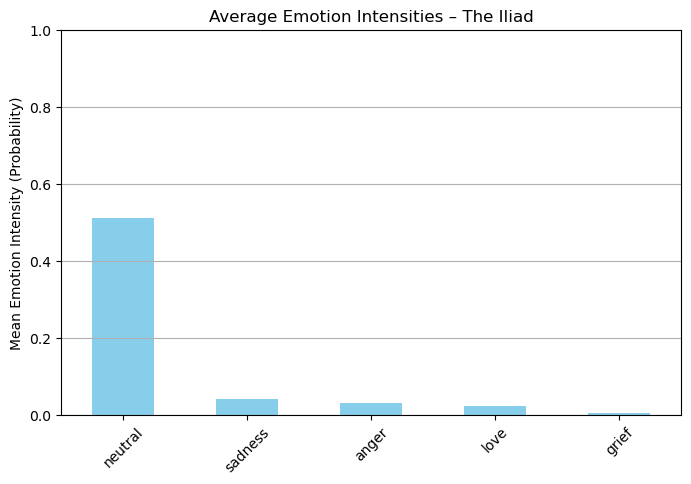

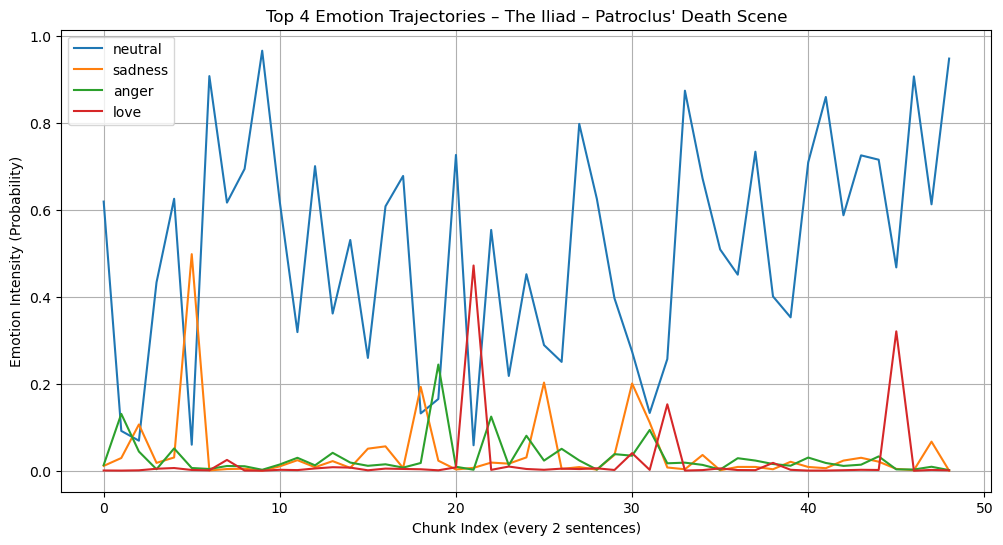

In [9]:
#visualise sentiment analysis-iliad
#compute mean emotion intensities and sort descending
iliad_avg = df_iliad[["grief", "love", "sadness", "anger", "neutral"]].mean().sort_values(ascending=False)

#visualize the emotion intensity
def plot_mean_emotions(emotion_means, title):
    plt.figure(figsize=(8, 5))
    emotion_means.plot(kind='bar', color='skyblue')
    plt.title(f"Average Emotion Intensities – {title}")
    plt.ylabel("Mean Emotion Intensity (Probability)")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()
plot_mean_emotions(iliad_avg, "The Iliad")

#visualize the trajectory
# Get top 4 for each
top4_iliad = iliad_avg.nlargest(4).index.tolist()


def plot_top4_emotions(df, top_emotions, title):
    plt.figure(figsize=(12, 6))
    for emotion in top_emotions:
        plt.plot(df["chunk_index"], df[emotion], label=emotion)
    plt.title(f"Top 4 Emotion Trajectories – {title}")
    plt.xlabel("Chunk Index (every 2 sentences)")
    plt.ylabel("Emotion Intensity (Probability)")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_top4_emotions(df_iliad, top4_iliad, "The Iliad – Patroclus' Death Scene")

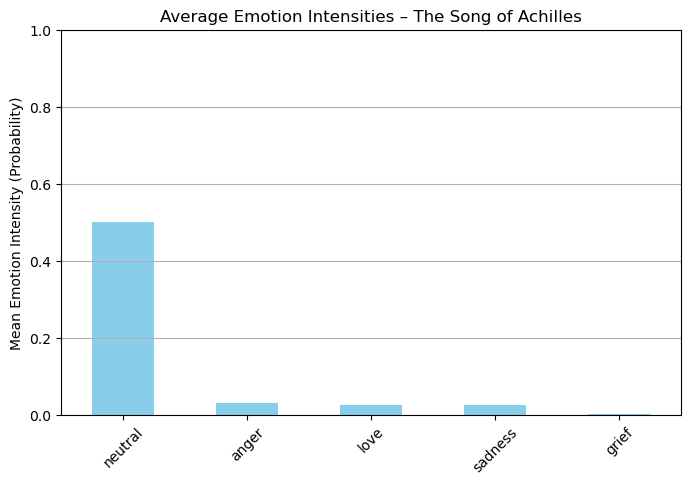

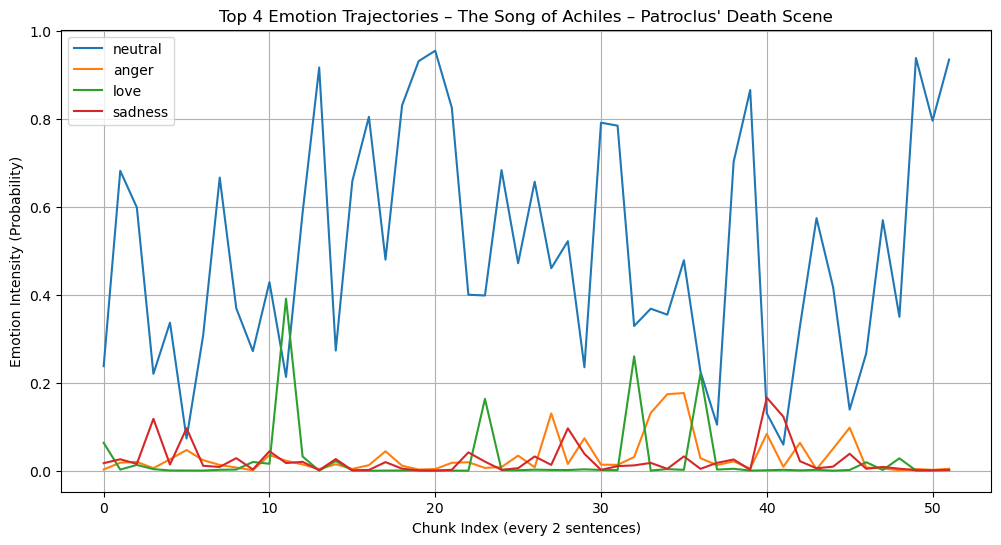

In [11]:
#visualise sentiment anaslysis-soa
##compute mean emotion intensities and sort descending
soa_avg = df_soa[["grief", "love", "sadness", "anger", "neutral"]].mean().sort_values(ascending=False)

#visualize the emotion intensity
def plot_mean_emotions(emotion_means, title):
    plt.figure(figsize=(8, 5))
    emotion_means.plot(kind='bar', color='skyblue')
    plt.title(f"Average Emotion Intensities – {title}")
    plt.ylabel("Mean Emotion Intensity (Probability)")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()
plot_mean_emotions(soa_avg, "The Song of Achilles")

#visualize the trajectory
# Get top 4 for each
top4_soa = soa_avg.nlargest(4).index.tolist()

def plot_top4_emotions(df, top_emotions, title):
    plt.figure(figsize=(12, 6))
    for emotion in top_emotions:
        plt.plot(df["chunk_index"], df[emotion], label=emotion)
    plt.title(f"Top 4 Emotion Trajectories – {title}")
    plt.xlabel("Chunk Index (every 2 sentences)")
    plt.ylabel("Emotion Intensity (Probability)")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_top4_emotions(df_soa, top4_soa, "The Song of Achiles – Patroclus' Death Scene")

Device set to use mps:0



=== The Iliad – Topic Modelling ===
    loss: 0.8529
   grief: 0.8268
     war: 0.7625
    fate: 0.7609
 destiny: 0.7385
   honor: 0.4868
love story: 0.4705


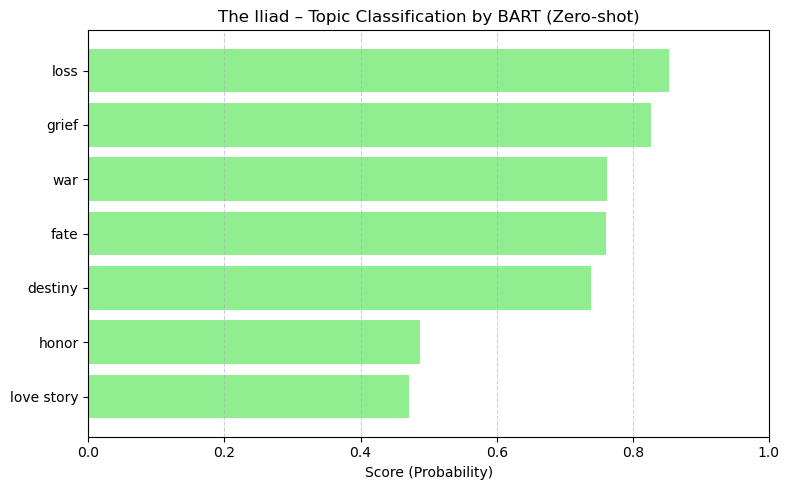

In [15]:
#topic modelling-iliaid
#import libraries
from transformers import pipeline

#load zero-shot classifier
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli",framework="pt")

#load mourning scenes from .txt files
with open("/Users/kojimmy/Desktop/iliaid.txt", "r", encoding="utf-8") as f:
    iliad_text = f.read()

#define candidate topic
labels = ["love story", "grief", "honor", "destiny", "war", "loss", "fate"]

#run zero-shot classification
iliad_result = classifier(iliad_text, candidate_labels=labels, multi_label=True)
#display results~
def show_results(title, result):
    print(f"\n=== {title} ===")
    for label, score in zip(result["labels"], result["scores"]):
        print(f"{label:>8}: {score:.4f}")

show_results("The Iliad – Topic Modelling", iliad_result)

#visualise bar chart
import matplotlib.pyplot as plt

def plot_results(result, title):
    labels = result["labels"]
    scores = result["scores"]

    plt.figure(figsize=(8, 5))
    plt.barh(labels[::-1], scores[::-1], color="lightgreen")  # reverse for top-to-bottom
    plt.xlabel("Score (Probability)")
    plt.title(title)
    plt.xlim(0, 1)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_results(iliad_result, "The Iliad – Topic Classification by BART (Zero-shot)")


Device set to use mps:0



=== The song of achilles – Topic Modelling ===
    fate: 0.8718
 destiny: 0.8461
love story: 0.8290
     war: 0.8249
    loss: 0.7189
   honor: 0.7122
   grief: 0.4349


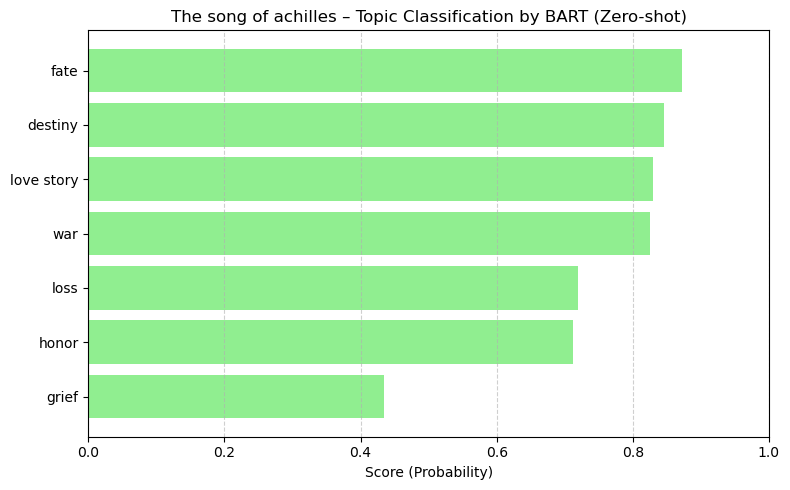

In [17]:
#topic modelling the song of achilles
from transformers import pipeline

#load zero-shot classifier
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli",framework="pt")

#load mourning scenes from .txt files
with open("/Users/kojimmy/Desktop/The song of achilles.txt", "r", encoding="utf-8") as f:
    soa_text = f.read()

#define candidate topics
labels = ["love story", "grief", "honor", "destiny", "war", "loss", "fate"]

#r zero-shot classification
soa_result = classifier(soa_text, candidate_labels=labels, multi_label=True)
#display results
def show_results(title, result):
    print(f"\n=== {title} ===")
    for label, score in zip(result["labels"], result["scores"]):
        print(f"{label:>8}: {score:.4f}")

show_results("The song of achilles – Topic Modelling", soa_result)

#visualise bar chart
import matplotlib.pyplot as plt

def plot_results(result, title):
    labels = result["labels"]
    scores = result["scores"]

    plt.figure(figsize=(8, 5))
    plt.barh(labels[::-1], scores[::-1], color="lightgreen")  # reverse for top-to-bottom
    plt.xlabel("Score (Probability)")
    plt.title(title)
    plt.xlim(0, 1)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_results(soa_result, "The song of achilles – Topic Classification by BART (Zero-shot)")


Device set to use mps:0



=== The Iliad – Patroclus' Death Scene ===
warrior bond: 0.7363
devotion: 0.6643
brotherhood: 0.6014
romantic relationship: 0.4043
friendship: 0.3467


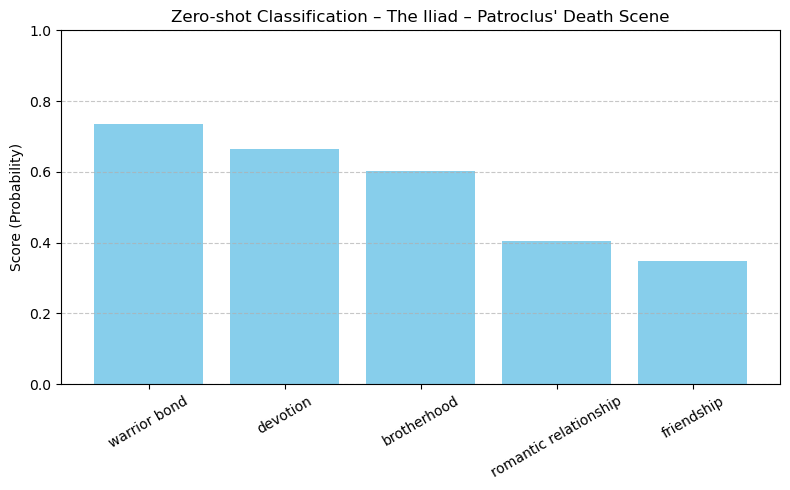

In [19]:
# relationship classificarion- iliad
#import library
from transformers import pipeline
import matplotlib.pyplot as plt

#load zero-shot classifier
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli",framework="pt",device=0)

#load mourning scenes from .txt files
with open("/Users/kojimmy/Desktop/iliaid.txt", "r", encoding="utf-8") as f:
    iliad_text = f.read()

#define candidate topic
labels = ["romantic relationship","brotherhood","friendship","devotion","warrior bond"]

#run zero-shot classification
iliad_result = classifier(iliad_text, candidate_labels=labels, multi_label=True) #the result is the python dictionary
#display results
def show_results(title, result):
    print(f"\n=== {title} ===")
    for label, score in zip(result["labels"], result["scores"]):
        print(f"{label:>8}: {score:.4f}")

show_results("The Iliad – Patroclus' Death Scene", iliad_result)

#visulaize 
#get labels and scores for x, y 
iliaid_labels= iliad_result["labels"]
iliaid_scores= iliad_result["scores"]
#plot
plt.figure(figsize=(8,5))
plt.bar(iliaid_labels, iliaid_scores, color='skyblue')
plt.title("Zero-shot Classification – The Iliad – Patroclus' Death Scene")
plt.ylabel("Score (Probability)")
plt.ylim(0, 1)  # Because scores are probability between 0 and 1
plt.xticks(rotation=30)  # Rotate x-labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Device set to use mps:0



=== The Song of Achilles – Patroclus' Death Scene ===
romantic relationship: 0.9051
warrior bond: 0.8996
brotherhood: 0.8088
devotion: 0.7947
friendship: 0.6517


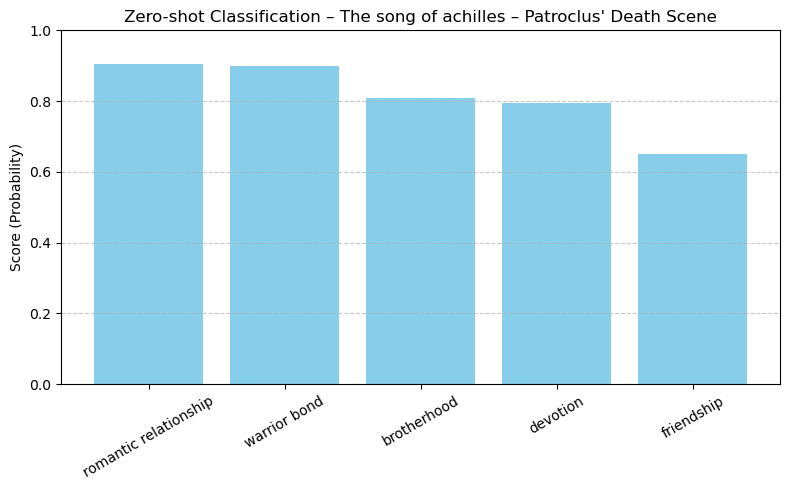

In [21]:
#relationship classification-soa
#import libraries
from transformers import pipeline
import matplotlib.pyplot as plt

#load zero-shot classifier
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli",framework="pt",device=0)

#load mourning scenes from .txt files
with open("/Users/kojimmy/Desktop/The song of achilles.txt", "r", encoding="utf-8") as f:
    soa_text = f.read()

#define candidate topics
labels = ["romantic relationship","brotherhood","friendship","devotion","warrior bond"]

#run zero-shot classification
soa_result = classifier(soa_text, candidate_labels=labels, multi_label=True)
#display results
def show_results(title, result):
    print(f"\n=== {title} ===")
    for label, score in zip(result["labels"], result["scores"]):
        print(f"{label:>8}: {score:.4f}")

show_results("The Song of Achilles – Patroclus' Death Scene", soa_result)

#visulaize 
#get labels and scores for x, y
soa_labels= soa_result["labels"]
soa_scores= soa_result["scores"]
#plot
plt.figure(figsize=(8,5))
plt.bar(soa_labels, soa_scores, color='skyblue')
plt.title("Zero-shot Classification – The song of achilles – Patroclus' Death Scene")
plt.ylabel("Score (Probability)")
plt.ylim(0, 1)  # Because scores are probability between 0 and 1
plt.xticks(rotation=30)  # Rotate x-labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
